In [1]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Path: put the Excel file next to this notebook, or set EXCEL_FILE manually ──
EXCEL_FILE = Path("benchmark_with_SLURM.xlsx")

# Fallback: search common locations if not found next to the notebook
if not EXCEL_FILE.exists():
    _candidates = [
        Path.home() / "OneDrive" / "EV-projects" / "evcs-projects" / "results" / "benchmarking" / "benchmark_with_SLURM.xlsx",
    ]
    for _p in _candidates:
        if _p.exists():
            EXCEL_FILE = _p
            break

assert EXCEL_FILE.exists(), f"Excel file not found: {EXCEL_FILE}"

df = pd.read_excel(EXCEL_FILE, sheet_name="benchmark")
print(f"Loaded {len(df)} rows from: {EXCEL_FILE}")
df[['Timestamp','Instance','N','T','D_km','seed','DR_best','Exact_incumbent_raw','Gap_%']]

Loaded 9 rows from: C:\Users\asus\OneDrive\EV-projects\evcs-projects\results\benchmarking\benchmark_with_SLURM.xlsx


,Timestamp,Instance,N,T,D_km,seed,DR_best,Exact_incumbent_raw,Gap_%
0,2026-04-06 16:45:33,center_102_Vicenza_k125,125,6,2,11,751.2292,751.733425,0.0671
1,2026-04-06 16:45:49,center_247_Reggio_Emilia_k125,125,6,2,11,749.4384,749.960492,0.0696
2,2026-04-06 16:46:54,center_153_Padova_k175,175,6,2,11,1034.3764,1035.779556,0.1355
3,2026-04-06 16:47:17,center_240_Parma_k200,200,6,2,11,1160.7179,1161.544692,0.0712
4,2026-04-06 16:48:01,center_323_Prato_k200,200,6,2,11,1160.5832,1161.346191,0.0657
5,2026-04-06 16:48:50,center_146_Verona_k250,250,6,2,11,1408.6489,1411.735909,0.2187
6,2026-04-06 16:49:12,center_58_Trieste_k225,225,6,2,11,1284.3931,1285.238826,0.0658
7,2026-04-06 17:01:46,center_79_Monza_k400,400,6,2,11,1983.7417,2009.965206,1.3047
8,2026-04-06 17:17:13,center_520_Bari_k400,400,6,2,11,1991.3224,2012.586273,1.0565


In [2]:
xl = pd.ExcelFile(EXCEL_FILE)
TRACE_SHEETS = sorted(
    [s for s in xl.sheet_names if s.startswith("t") and s[1:].isdigit()],
    key=lambda s: int(s[1:])
)
print("Trace sheets:", TRACE_SHEETS)

# Build a lookup: trace_sheet_name -> benchmark row
# Uses the 'Trace_sheet' column for a reliable match (not positional index)
_trace_map = (
    df.dropna(subset=["Trace_sheet"])
      .set_index("Trace_sheet")
)


def get_trace_for_sheet(sheet_name):
    return xl.parse(sheet_name)


def row_for_sheet(sheet_name):
    """Return the benchmark row for this trace sheet, or None if not found."""
    if sheet_name in _trace_map.index:
        return _trace_map.loc[sheet_name]
    return None


def plot_dr_curve(ax, trace, row, sheet_name):
    x    = trace["iteration"].to_numpy()
    best = trace["best_full"].ffill().to_numpy()

    # Fluctuating current line (proxy_max shown as thin blue, matching the reference image)
    if "proxy_max" in trace.columns:
        ax.plot(x, trace["proxy_max"].to_numpy(), linewidth=1.0, alpha=0.55,
                color="tab:blue", label="DR fluctuating (current)")
    elif "proxy_mean" in trace.columns:
        ax.plot(x, trace["proxy_mean"].to_numpy(), linewidth=1.0, alpha=0.55,
                color="tab:blue", label="DR fluctuating (proxy mean)")

    # DR best-so-far (thick orange)
    ax.plot(x, best, linewidth=2.5, color="tab:orange",
            label=f"DR best-so-far (best_full)")

    if row is not None:
        instance = row["Instance"]
        N        = int(row["N"])
        T        = int(row["T"])
        seed     = int(row["seed"])
        policy   = row.get("Policy", "")
        exact    = row["Exact_incumbent_raw"]
        gap      = row["Gap_%"]

        if pd.notna(exact):
            ax.axhline(y=float(exact), linestyle="--", linewidth=2.0,
                       color="tab:blue", label=f"Exact ({float(exact):.3f})")

        gap_str = f"{gap:.4f}%" if pd.notna(gap) else "N/A"
        title = (
            f"DR vs Exact  |  N={N}, T={T}, seed={seed}  |  policy={policy}\n"
            f"{instance}  —  Gap={gap_str},  DR={best[-1]:.3f},  iters={len(x)}"
        )
    else:
        title = f"Sheet {sheet_name}  (no benchmark metadata)\niters={len(x)}"

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("iteration", fontsize=9)
    ax.set_ylabel("Score", fontsize=9)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
    ax.grid(True, linewidth=0.5)


print("Helper functions ready.")

Trace sheets: ['t15', 't16', 't17', 't18', 't19', 't20', 't21', 't22', 't23']
Helper functions ready.


In [3]:
plottable = []
for sh in TRACE_SHEETS:
    trace = get_trace_for_sheet(sh)
    row   = row_for_sheet(sh)
    if row is not None:
        label = f"{row['Instance']} (N={int(row['N'])})"
    else:
        label = f"sheet {sh} — no benchmark metadata"
    print(f"  {sh}: {label}")
    plottable.append((sh, row, trace))

print(f"\n{len(plottable)} trace sheet(s) to plot.")

  t15: center_102_Vicenza_k125 (N=125)
  t16: center_247_Reggio_Emilia_k125 (N=125)
  t17: center_153_Padova_k175 (N=175)
  t18: center_240_Parma_k200 (N=200)
  t19: center_323_Prato_k200 (N=200)
  t20: center_146_Verona_k250 (N=250)
  t21: center_58_Trieste_k225 (N=225)
  t22: center_79_Monza_k400 (N=400)
  t23: center_520_Bari_k400 (N=400)

9 trace sheet(s) to plot.


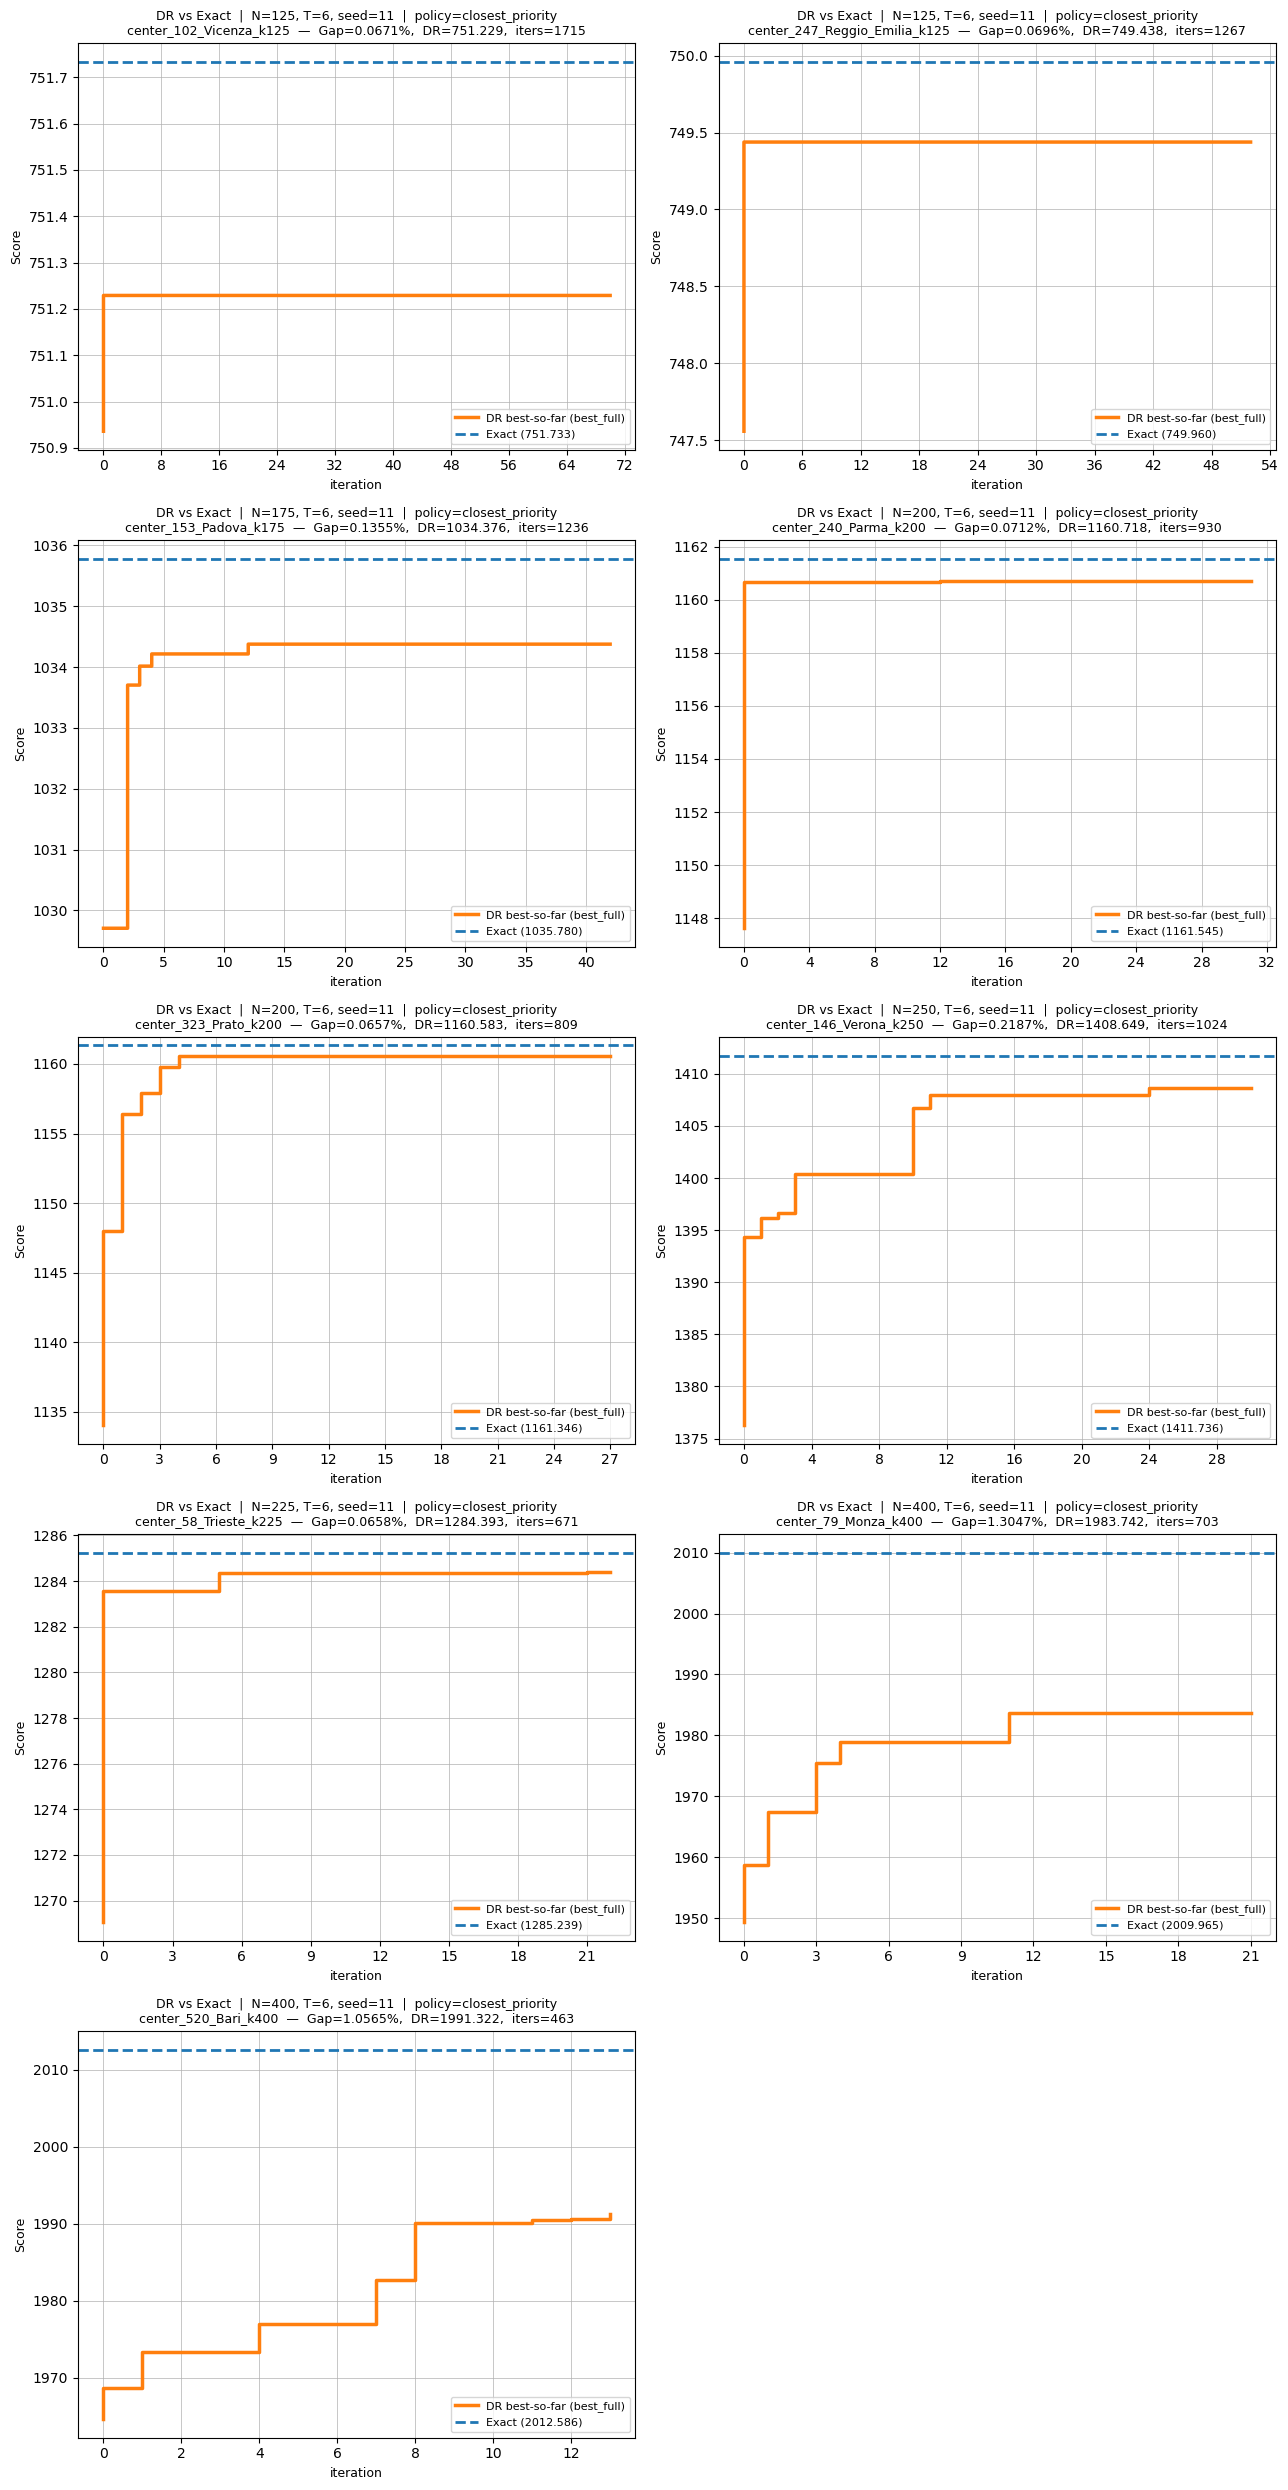

In [4]:
ncols = 2
nrows = int(np.ceil(len(plottable) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 5 * nrows))
axes = np.array(axes).reshape(-1)

for i, (sh, row, trace) in enumerate(plottable):
    plot_dr_curve(axes[i], trace, row, sh)

# Hide unused subplots
for i in range(len(plottable), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
# ── Summary table with color-coded gap ──────────────────────────────────────
cols = ['Timestamp','Instance','Policy','N','T','D_km','seed',
        'Exact_incumbent_raw','DR_best','Gap_%','DR_iters','DR_time_s','Exact_time_s']
show = [c for c in cols if c in df.columns]
df[show].style \
    .format({'Exact_incumbent_raw':'{:.4f}','DR_best':'{:.4f}',
             'Gap_%':'{:.4f}%','DR_time_s':'{:.1f}s','Exact_time_s':'{:.1f}s'}) \
    .background_gradient(subset=['Gap_%'], cmap='RdYlGn_r')

,Timestamp,Instance,Policy,N,T,D_km,seed,Exact_incumbent_raw,DR_best,Gap_%,DR_iters,DR_time_s,Exact_time_s
0,2026-04-06 16:45:33,center_102_Vicenza_k125,closest_priority,125,6,2,11,751.7334,751.2292,0.0671%,1715,1007.4s,12.0s
1,2026-04-06 16:45:49,center_247_Reggio_Emilia_k125,closest_priority,125,6,2,11,749.9605,749.4384,0.0696%,1267,1017.5s,17.2s
2,2026-04-06 16:46:54,center_153_Padova_k175,closest_priority,175,6,2,11,1035.7796,1034.3764,0.1355%,1236,1016.7s,82.0s
3,2026-04-06 16:47:17,center_240_Parma_k200,closest_priority,200,6,2,11,1161.5447,1160.7179,0.0712%,930,1021.4s,101.4s
4,2026-04-06 16:48:01,center_323_Prato_k200,closest_priority,200,6,2,11,1161.3462,1160.5832,0.0657%,809,1024.5s,142.7s
5,2026-04-06 16:48:50,center_146_Verona_k250,closest_priority,250,6,2,11,1411.7359,1408.6489,0.2187%,1024,1027.7s,188.7s
6,2026-04-06 16:49:12,center_58_Trieste_k225,closest_priority,225,6,2,11,1285.2388,1284.3931,0.0658%,671,1031.4s,207.1s
7,2026-04-06 17:01:46,center_79_Monza_k400,closest_priority,400,6,2,11,2009.9652,1983.7417,1.3047%,703,1029.2s,962.9s
8,2026-04-06 17:17:13,center_520_Bari_k400,closest_priority,400,6,2,11,2012.5863,1991.3224,1.0565%,463,1044.5s,1874.5s
